# Generate Deferral Explanation Figures

This notebook:
1. Trains L2D model on Broward/COMPAS data
2. Generates counterfactuals for all deferred instances
3. Reverses normalization to get human-readable values
4. Creates Figure 1-style outputs (TikZ + Matplotlib) for each deferred instance

In [44]:
import torch
import torch.optim as optim
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from pathlib import Path
import os

# Your local imports
import scripts
from defer.helpers.metrics import compute_deferral_metrics
from defer.networks.non_linear_net import NonLinearNet
from defer.methods.realizable_surrogate import RealizableSurrogate
from defer.datasetsdefer.broward import BrowardDataset

## 1. Setup and Configuration

In [45]:
# Configuration - adjust these paths if needed
DATA_DIR = "defer/data"
RAW_CSV_PATH = "defer/data/allDataBroward/BROWARD_CLEAN_SUBSET.csv"
OUTPUT_DIR = "results/defer_figures"

# Create output directory
Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)

# Feature names (after dropping block_num, id, two_year_recid)
FEATURE_NAMES = ['race', 'sex', 'age', 'juv_fel_count', 'juv_misd_count', 
                 'priors_count', 'charge_id', 'charge_degree', 'compas_decile_score']

# Human-readable feature names for display
FEATURE_DISPLAY_NAMES = {
    'race': 'Race',
    'sex': 'Sex',
    'age': 'Age',
    'juv_fel_count': 'Juvenile Felonies',
    'juv_misd_count': 'Juvenile Misdemeanors',
    'priors_count': 'Prior Offenses',
    'charge_id': 'Charge ID',
    'charge_degree': 'Charge Degree',
    'compas_decile_score': 'COMPAS Score'
}

## 2. Load Data and Fit Scaler for Inverse Transform

In [46]:
# Load raw data to fit scaler (for reversing normalization)
raw_data = pd.read_csv(RAW_CSV_PATH)
raw_data_features = raw_data.drop(["block_num", "id", "two_year_recid"], axis=1)

# Fit scaler on raw data
scaler = StandardScaler()
scaler.fit(raw_data_features.values)

print(f"Loaded {len(raw_data)} samples")
print(f"Features: {list(raw_data_features.columns)}")
print(f"\nScaler means: {dict(zip(FEATURE_NAMES, scaler.mean_))}")
print(f"\nScaler stds: {dict(zip(FEATURE_NAMES, scaler.scale_))}")

Loaded 1000 samples
Features: ['race', 'sex', 'age', 'juv_fel_count', 'juv_misd_count', 'priors_count', 'charge_id', 'charge_degree (misd/fel)', 'compas_decile_score']

Scaler means: {'race': 1.725, 'sex': 0.197, 'age': 34.611, 'juv_fel_count': 0.061, 'juv_misd_count': 0.103, 'priors_count': 3.432, 'charge_id': 175.193, 'charge_degree': 0.622, 'compas_decile_score': 4.574}

Scaler stds: {'race': 0.6506727287968967, 'sex': 0.39773232204587045, 'age': 12.034354116445137, 'juv_fel_count': 0.4419038356927896, 'juv_misd_count': 0.47790270976423643, 'priors_count': 5.005534536890141, 'charge_id': 117.60408900629264, 'charge_degree': 0.48488761584515644, 'compas_decile_score': 2.8709796237521434}


In [47]:
def inverse_transform_sample(normalized_values, scaler, feature_names):
    """
    Convert normalized values back to original scale.
    Returns a dictionary with feature names as keys.
    """
    if isinstance(normalized_values, torch.Tensor):
        normalized_values = normalized_values.detach().numpy()
    
    normalized_values = np.array(normalized_values).reshape(1, -1)
    original_values = scaler.inverse_transform(normalized_values).flatten()
    
    return dict(zip(feature_names, original_values))

## 3. Expert Estimation (from your existing code)

In [48]:
from dataclasses import dataclass
import torch.nn.functional as F
from torch.optim import Adam

@dataclass
class EstimatedExpert:
    """Expert model with parameters compatible with expert_predict_proba function."""
    fpr_beta: float
    fnr_beta: float
    alpha: float
    w: np.ndarray
    
    def __post_init__(self):
        self.w = np.asarray(self.w)


def estimate_expert_parameters(X, y, m, learning_rate=0.01, n_epochs=2000, verbose=False):
    """
    Estimate expert parameters using MLE with PyTorch and Adam.
    """
    X_tensor = torch.FloatTensor(X)
    y_tensor = torch.FloatTensor(y)
    m_tensor = torch.FloatTensor(m)
    
    n_samples, n_features = X.shape
    
    fp_rate = ((y == 0) & (m == 1)).sum() / (y == 0).sum()
    fn_rate = ((y == 1) & (m == 0)).sum() / (y == 1).sum()
    
    fp_rate = np.clip(fp_rate, 0.01, 0.99)
    fn_rate = np.clip(fn_rate, 0.01, 0.99)
    
    beta0 = torch.tensor(np.log(fp_rate / (1 - fp_rate)), requires_grad=True)
    beta1 = torch.tensor(np.log(fn_rate / (1 - fn_rate)), requires_grad=True)
    alpha = torch.tensor(1.0, requires_grad=True)
    
    w_init = np.random.randn(n_features)
    w_init = w_init / np.linalg.norm(w_init)
    w = torch.tensor(w_init, dtype=torch.float32, requires_grad=True)
    
    parameters = [beta0, beta1, alpha, w]
    optimizer = Adam(parameters, lr=learning_rate)
    
    best_loss = float('inf')
    best_params = None
    
    for epoch in range(n_epochs):
        optimizer.zero_grad()
        
        w_norm = torch.clamp(torch.norm(w), min=1e-6)
        projections = torch.matmul(X_tensor, w) / w_norm
        
        p_fp_error = torch.sigmoid(beta0 + alpha * projections)
        p_fn_error = torch.sigmoid(beta1 - alpha * projections)
        
        neg_mask = (y_tensor == 0)
        neg_correct = neg_mask & (m_tensor == 0)
        neg_error = neg_mask & (m_tensor == 1)
        
        pos_mask = (y_tensor == 1)
        pos_correct = pos_mask & (m_tensor == 1)
        pos_error = pos_mask & (m_tensor == 0)
        
        ll_neg_correct = torch.sum(torch.log(1 - p_fp_error[neg_correct] + 1e-10))
        ll_neg_error = torch.sum(torch.log(p_fp_error[neg_error] + 1e-10))
        ll_pos_correct = torch.sum(torch.log(1 - p_fn_error[pos_correct] + 1e-10))
        ll_pos_error = torch.sum(torch.log(p_fn_error[pos_error] + 1e-10))
        
        log_likelihood = ll_neg_correct + ll_neg_error + ll_pos_correct + ll_pos_error
        
        reg_strength = 0.01
        regularization = reg_strength * (beta0**2 + beta1**2 + alpha**2 + torch.sum(w**2))
        
        loss = -log_likelihood + regularization
        loss.backward()
        
        torch.nn.utils.clip_grad_norm_(parameters, max_norm=5.0)
        optimizer.step()
        
        with torch.no_grad():
            alpha.data = torch.clamp(alpha.data, min=0.1)
        
        if loss.item() < best_loss:
            best_loss = loss.item()
            best_params = {
                'beta0': beta0.detach().clone(),
                'beta1': beta1.detach().clone(),
                'alpha': alpha.detach().clone(),
                'w': w.detach().clone()
            }
        
        if verbose and epoch % 500 == 0:
            print(f"Epoch {epoch}: Loss = {loss.item():.4f}")
    
    return EstimatedExpert(
        fpr_beta=best_params['beta0'].item(),
        fnr_beta=best_params['beta1'].item(),
        alpha=best_params['alpha'].item(),
        w=best_params['w'].numpy()
    )

## 4. Load Dataset and Train L2D Model

In [49]:
def load_broward_dataset():
    """Load Broward dataset and estimate expert."""
    dataset = BrowardDataset(DATA_DIR)
    
    # Get feature names from raw data
    broward_data = pd.read_csv(RAW_CSV_PATH)
    broward_data = broward_data.drop(["block_num", "id", "two_year_recid"], axis=1)
    feature_names = list(broward_data.columns)
    
    # Estimate expert from training data
    X_train, y_train, h_train = list(dataset.data_train_loader)[0]
    expert = estimate_expert_parameters(
        X_train.detach().numpy(), 
        y_train.detach().numpy(), 
        h_train.detach().numpy(),
        verbose=True
    )
    
    return expert, dataset, feature_names


print("Loading dataset and estimating expert...")
expert, dataset, feature_names = load_broward_dataset()
print(f"\nFeature names: {feature_names}")

Loading dataset and estimating expert...
Epoch 0: Loss = 445.8654
Epoch 500: Loss = 155.0668
Epoch 1000: Loss = 143.7546
Epoch 1500: Loss = 143.0150

Feature names: ['race', 'sex', 'age', 'juv_fel_count', 'juv_misd_count', 'priors_count', 'charge_id', 'charge_degree (misd/fel)', 'compas_decile_score']


In [54]:
def train_l2d_model(dataset, expert):
    """Train L2D model using Realizable Surrogate."""
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")
    
    optimizer = optim.Adam
    lr = 1e-2
    total_epochs = 100
    
    model = NonLinearNet(dataset.d, 3).to(device)
    L2D = RealizableSurrogate(1, 300, model, device, True)
    
    L2D.fit_hyperparam(
        dataset.data_train_loader,
        dataset.data_val_loader,
        dataset.data_test_loader,
        epochs=total_epochs,
        optimizer=optimizer,
        scheduler=None,
        lr=lr,
        verbose=True,
        test_interval=5,
    )
    
    metrics = compute_deferral_metrics(L2D.test(dataset.data_test_loader))
    factual_df, factuals = scripts.utils.build_factual_df(L2D, dataset, expert, defer_only=True)
    
    return L2D, metrics, factual_df, factuals


print("Training L2D model...")
L2D, metrics, factual_df, factuals = train_l2d_model(dataset, expert)
print(f"\nMetrics: {metrics}")
print(f"Number of deferred instances: {len(factuals)}")

Training L2D model...
Using device: cpu


  0%|                                                                       | 0/100 [00:00<?, ?it/s]/Users/antonio/Documents/Projects/XAI_ExplainableAI/defer/methods/realizable_surrogate.py:21: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  human_correct = torch.tensor(human_correct).to(self.device)
/opt/miniconda3/lib/python3.10/site-packages/numpy/lib/function_base.py:520: RuntimeWarning: Mean of empty slice.
  avg = a.mean(axis, **keepdims_kw)
/opt/miniconda3/lib/python3.10/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)

  6%|███▊                                                           | 6/100 [00:00<00:01, 52.57it/s]/Users/antonio/Documents/Projects/XAI_ExplainableAI/defer/methods/realizable_surrogate.py:21: UserWarning: To copy construct fro


Metrics: {'classifier_all_acc': 0.72, 'human_all_acc': 0.67, 'coverage': 0.355, 'classifier_nondeferred_acc': 0.8169014084507042, 'human_deferred_acc': 0.5891472868217055, 'system_acc': 0.67}
Number of deferred instances: 22


/opt/miniconda3/lib/python3.10/site-packages/numpy/lib/function_base.py:520: RuntimeWarning: Mean of empty slice.
  avg = a.mean(axis, **keepdims_kw)
/opt/miniconda3/lib/python3.10/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


## 5. Generate Counterfactuals

In [55]:
def obtain_counterfactuals(l2d, factuals, factual_df, metrics, expert):
    """Generate counterfactuals for all deferred instances."""
    perturbations, counter_df = scripts.counterfactual.find_defer_counterfactuals_parallel(
        model=l2d.model,
        test_x=factuals,
        threshold_rej=0,
        n_jobs=-1
    )
    
    counter_df = scripts.utils.probe_counterfactuals(counter_df, perturbations, factuals, expert, l2d)
    df_merged = factual_df.join(counter_df[["cfs_entropy", "cfs_expected_expert_err"]], how="inner")
    
    # Classify deferral types
    isTypeI = df_merged["entropy"] > df_merged["cfs_entropy"]
    isTypeII = df_merged["cfs_expected_expert_err"] > df_merged["expected_expert_err"]
    
    df_merged["is_type_i"] = isTypeI
    df_merged["is_type_ii"] = isTypeII
    df_merged["defer_type"] = "unclear"
    df_merged.loc[isTypeI & ~isTypeII, "defer_type"] = "type_i"
    df_merged.loc[~isTypeI & isTypeII, "defer_type"] = "type_ii"
    df_merged.loc[isTypeI & isTypeII, "defer_type"] = "mixed"
    
    metrics["n_type1"] = np.sum(isTypeI)
    metrics["n_type2"] = np.sum(isTypeII)
    metrics["n_only_type1"] = np.sum(isTypeI & ~isTypeII)
    metrics["n_only_type2"] = np.sum(isTypeII & ~isTypeI)
    metrics["n_mixed"] = np.sum(isTypeI & isTypeII)
    metrics["n_defer"] = df_merged.shape[0]
    
    return metrics, df_merged, perturbations


print("Generating counterfactuals...")
metrics, df_merged, perturbations = obtain_counterfactuals(L2D, factuals, factual_df, metrics, expert)

print(f"\nDeferral type breakdown:")
print(f"  Type I (uncertainty): {metrics['n_only_type1']}")
print(f"  Type II (expert superiority): {metrics['n_only_type2']}")
print(f"  Mixed: {metrics['n_mixed']}")
print(f"  Total deferred: {metrics['n_defer']}")

Generating counterfactuals...
Processing 22 samples for defer counterfactuals in parallel...

Deferral type breakdown:
  Type I (uncertainty): 10
  Type II (expert superiority): 0
  Mixed: 2
  Total deferred: 12


## 6. Figure Generation Functions

In [56]:
def get_defer_type_label(defer_type):
    """Get human-readable label for defer type."""
    labels = {
        "type_i": "Type I: \"I'm Not Sure\"",
        "type_ii": "Type II: \"You Know Better\"",
        "mixed": "Mixed: Both Uncertainty and Expert Superiority",
        "unclear": "Unclear"
    }
    return labels.get(defer_type, defer_type)


def get_feature_changes(factual_orig, counterfactual_orig, feature_names, threshold=0.01):
    """
    Get list of features that changed significantly.
    Uses ORIGINAL (non-normalized) values.
    """
    changes = []
    for fname, f_val, cf_val in zip(feature_names, factual_orig, counterfactual_orig):
        change = cf_val - f_val
        # Use relative threshold for features with larger values
        rel_change = abs(change) / (abs(f_val) + 1e-6)
        if abs(change) >= threshold or rel_change >= 0.05:
            changes.append({
                'name': fname,
                'display_name': FEATURE_DISPLAY_NAMES.get(fname, fname),
                'original': f_val,
                'counterfactual': cf_val,
                'change': change,
                'abs_change': abs(change)
            })
    
    # Sort by absolute change
    changes.sort(key=lambda x: x['abs_change'], reverse=True)
    return changes

In [57]:
def create_matplotlib_figure(index, factual_orig, counterfactual_orig, data_row, 
                             feature_names, feature_changes, save_path=None):
    """
    Create matplotlib figure with feature bar plot and explanation text.
    Uses ORIGINAL (non-normalized) values.
    """
    defer_type = data_row["defer_type"]
    confidence = 1 - data_row["entropy"]
    cf_confidence = 1 - data_row["cfs_entropy"]
    expert_perf = 1 - data_row["expected_expert_err"]
    cf_expert_perf = 1 - data_row["cfs_expected_expert_err"]
    
    # Filter to top 5 changes
    top_changes = feature_changes[:5]
    
    if not top_changes:
        print(f"  Warning: No significant feature changes for instance {index}")
        return None
    
    # Create figure
    fig, axes = plt.subplots(1, 2, figsize=(12, max(3, 0.6 * len(top_changes))), 
                             gridspec_kw={'width_ratios': [1, 1.5]})
    ax_bar, ax_text = axes
    
    # === Left panel: Feature bar plot ===
    y_positions = range(len(top_changes))
    feature_labels = [c['display_name'] for c in top_changes]
    original_vals = [c['original'] for c in top_changes]
    cf_vals = [c['counterfactual'] for c in top_changes]
    
    for y, orig, cf in zip(y_positions, original_vals, cf_vals):
        color = '#FF0059' if cf > orig else '#0283F8'
        
        # Draw arrow
        ax_bar.annotate('', xy=(cf, y), xytext=(orig, y),
                       arrowprops=dict(arrowstyle='->', color='black', lw=1.5,
                                      shrinkA=5, shrinkB=5))
        # Plot points
        ax_bar.scatter(orig, y, color='black', s=80, zorder=3, label='Factual' if y == 0 else '')
        ax_bar.scatter(cf, y, color=color, s=80, zorder=3, label='Counterfactual' if y == 0 else '')
    
    ax_bar.set_yticks(y_positions)
    ax_bar.set_yticklabels(feature_labels)
    ax_bar.invert_yaxis()
    ax_bar.set_xlabel('Value (Original Scale)')
    ax_bar.grid(axis='x', linestyle='--', linewidth=0.5, alpha=0.7)
    ax_bar.spines[['top', 'right']].set_visible(False)
    ax_bar.legend(loc='lower right', frameon=False)
    
    # === Right panel: Explanation text ===
    ax_text.axis('off')
    
    # Build explanation text
    type_label = get_defer_type_label(defer_type)
    
    if defer_type == "type_i":
        explanation = f"{type_label}\n\n"
        explanation += f"The model deferred due to low confidence.\n"
        explanation += f"• Current confidence: {confidence:.1%}\n"
        explanation += f"• Prediction: Class {int(data_row['model_pred'])}\n\n"
        explanation += "The model would NOT have deferred if:\n"
    elif defer_type == "type_ii":
        explanation = f"{type_label}\n\n"
        explanation += f"The model deferred because the expert performs better here.\n"
        explanation += f"• Expected expert accuracy: {expert_perf:.1%}\n"
        explanation += f"• Model confidence: {confidence:.1%}\n\n"
        explanation += "The model would NOT have deferred if:\n"
    elif defer_type == "mixed":
        explanation = f"{type_label}\n\n"
        explanation += f"The model deferred for TWO reasons:\n"
        explanation += f"1. Low confidence: {confidence:.1%}\n"
        explanation += f"2. High expected expert performance: {expert_perf:.1%}\n\n"
        explanation += "The model would NOT have deferred if:\n"
    else:
        explanation = f"{type_label}\n\n"
        explanation += "Changes that would prevent deferral:\n"
    
    # Add feature changes
    for fc in top_changes:
        direction = "↑" if fc['change'] > 0 else "↓"
        explanation += f"  • {fc['display_name']}: {fc['original']:.2f} → {fc['counterfactual']:.2f} {direction}\n"
    
    # Add result
    explanation += f"\nResult of these changes:\n"
    explanation += f"  • Confidence: {confidence:.1%} → {cf_confidence:.1%}\n"
    explanation += f"  • Expected expert perf: {expert_perf:.1%} → {cf_expert_perf:.1%}\n"
    explanation += f"  • Model would predict: Class {int(data_row['model_pred'])}"
    
    ax_text.text(0.05, 0.95, explanation, transform=ax_text.transAxes,
                fontsize=10, verticalalignment='top', fontfamily='monospace',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.suptitle(f'Deferral Explanation - Instance {index}', fontsize=12, fontweight='bold')
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=150)
        plt.close()
    
    return fig

In [58]:
def generate_tikz_code(index, factual_orig, counterfactual_orig, data_row, 
                       feature_names, feature_changes):
    """
    Generate TikZ code for Figure 1-style explanation.
    Uses ORIGINAL (non-normalized) values.
    """
    defer_type = data_row["defer_type"]
    confidence = 1 - data_row["entropy"]
    cf_confidence = 1 - data_row["cfs_entropy"]
    expert_perf = 1 - data_row["expected_expert_err"]
    cf_expert_perf = 1 - data_row["cfs_expected_expert_err"]
    model_pred = int(data_row['model_pred'])
    
    top_changes = feature_changes[:3]  # Top 3 for compact display
    
    # Determine colors based on type
    if defer_type == "type_i":
        header_color = "clr_blue"
        header_text = "Type I: \"I'm Not Sure\""
    elif defer_type == "type_ii":
        header_color = "clr_red"
        header_text = "Type II: \"You Know Better\""
    elif defer_type == "mixed":
        header_color = "clr_purple"
        header_text = "Mixed Type"
    else:
        header_color = "clr_gray"
        header_text = "Unclear"
    
    # Build feature string
    feature_lines = []
    for fc in top_changes:
        # Format based on feature type
        if fc['name'] in ['age', 'priors_count', 'juv_fel_count', 'juv_misd_count', 'compas_decile_score']:
            feature_lines.append(f"{fc['display_name']}: {fc['original']:.0f}")
        elif fc['name'] == 'sex':
            sex_label = 'Male' if fc['original'] > 0.5 else 'Female'
            feature_lines.append(f"Sex: {sex_label}")
        else:
            feature_lines.append(f"{fc['display_name']}: {fc['original']:.1f}")
    
    features_str = "\\\\ \n        ".join(feature_lines)
    
    # Build counterfactual change string
    cf_lines = []
    for fc in top_changes:
        if fc['name'] in ['age', 'priors_count', 'juv_fel_count', 'juv_misd_count', 'compas_decile_score']:
            cf_lines.append(f"\\textcolor{{{header_color}}}{{$\\rightarrow$ \\textbf{{{fc['display_name']}}} changed ${fc['original']:.0f} \\to {fc['counterfactual']:.0f}$}}")
        else:
            cf_lines.append(f"\\textcolor{{{header_color}}}{{$\\rightarrow$ \\textbf{{{fc['display_name']}}} changed ${fc['original']:.1f} \\to {fc['counterfactual']:.1f}$}}")
    
    cf_str = "\\\\ \n        ".join(cf_lines)
    
    # Diagnosis text
    if defer_type == "type_i":
        diagnosis = f"\\textit{{Low confidence in prediction}}\\\\ \n        Confidence: {confidence:.0%}"
        cf_explanation = f"Confidence would increase to \\textbf{{non-defer}} level if:"
    elif defer_type == "type_ii":
        diagnosis = f"\\textit{{High expected expert performance}}\\\\ \n        Expert Acc: {expert_perf:.0%}"
        cf_explanation = f"Model would \\textbf{{take over}} (not defer) if:"
    else:
        diagnosis = f"\\textit{{Low confidence + High expert perf}}\\\\ \n        Confidence: {confidence:.0%}, Expert: {expert_perf:.0%}"
        cf_explanation = f"Model would \\textbf{{take over}} if:"
    
    tikz_code = f"""
% Instance {index} - {header_text}
\\begin{{tikzpicture}}[
    font=\\sffamily,
    node distance=0.15cm,
    col_width/.style={{text width=4.5cm, align=left}},
    header/.style={{font=\\bfseries\\small, col_width}},
    label/.style={{font=\\tiny\\scshape, text=clr_gray, inner sep=0pt, col_width}},
    content/.style={{font=\\scriptsize, col_width, inner sep=2pt}},
    divider/.style={{thick, dashed, clr_gray!40}}
]

    % Header
    \\node[header, text={header_color}] (h1) {{{header_text}}};
    
    % Input Features
    \\node[label, below=0.2cm of h1] (l1_feat) {{Input Features}};
    \\node[content, below=0.05cm of l1_feat] (c1_feat) {{
        {features_str}
    }};
    \\node[content, below=0.1cm of c1_feat] (pred1) {{Prediction: \\textbf{{DEFERRED}}}};

    % Divider
    \\draw[divider] ($(pred1.south west)$) -- ($(pred1.south east)$);

    % Diagnosis
    \\node[label, below=0.2cm of pred1] (l1_diag) {{Diagnosis}};
    \\node[content, below=0.05cm of l1_diag] (c1_diag) {{
        {diagnosis}
    }};

    % Counterfactual Explanation
    \\node[label, below=0.2cm of c1_diag] (l1_exp) {{Counterfactual Explanation}};
    \\node[content, below=0.05cm of l1_exp] (c1_exp) {{
        {cf_explanation}\\\\
        {cf_str}
    }};

\\end{{tikzpicture}}
"""
    
    return tikz_code

def generate_tikz_code(index, factual_orig, counterfactual_orig, data_row, 
                       feature_names, feature_changes):
    """
    Generate TikZ code for Figure 1-style explanation.
    Uses ORIGINAL (non-normalized) values.
    Enhanced version with full explanation details.
    """
    defer_type = data_row["defer_type"]
    confidence = 1 - data_row["entropy"]
    cf_confidence = 1 - data_row["cfs_entropy"]
    expert_perf = 1 - data_row["expected_expert_err"]
    cf_expert_perf = 1 - data_row["cfs_expected_expert_err"]
    model_pred = int(data_row['model_pred'])
    
    top_changes = feature_changes[:3]  # Top 3 for compact display
    
    # Determine colors and text based on type
    if defer_type == "type_i":
        header_color = "clr_blue"
        header_text = "Type I: ``I'm Not Sure''"
        diagnosis_text = "Low confidence in prediction"
        diagnosis_metric = f"Confidence: {confidence:.0%}"
        cf_intro = "Confidence would increase if:"
        result_primary = f"Confidence: {confidence:.0%} $\\rightarrow$ {cf_confidence:.0%}"
        result_secondary = f"Expert perf: {expert_perf:.0%} $\\rightarrow$ {cf_expert_perf:.0%}"
    elif defer_type == "type_ii":
        header_color = "clr_red"
        header_text = "Type II: ``You Know Better''"
        diagnosis_text = "High expected expert performance"
        diagnosis_metric = f"Expert Acc: {expert_perf:.0%}"
        cf_intro = "Model would take over if:"
        result_primary = f"Expert perf: {expert_perf:.0%} $\\rightarrow$ {cf_expert_perf:.0%}"
        result_secondary = f"Confidence: {confidence:.0%} $\\rightarrow$ {cf_confidence:.0%}"
    elif defer_type == "mixed":
        header_color = "clr_purple"
        header_text = "Mixed Type"
        diagnosis_text = "Low confidence \\& high expert perf"
        diagnosis_metric = f"Conf: {confidence:.0%}, Expert: {expert_perf:.0%}"
        cf_intro = "Model would take over if:"
        result_primary = f"Confidence: {confidence:.0%} $\\rightarrow$ {cf_confidence:.0%}"
        result_secondary = f"Expert perf: {expert_perf:.0%} $\\rightarrow$ {cf_expert_perf:.0%}"
    else:
        header_color = "clr_gray"
        header_text = "Unclear"
        diagnosis_text = "Deferral reason unclear"
        diagnosis_metric = f"Conf: {confidence:.0%}, Expert: {expert_perf:.0%}"
        cf_intro = "Changes to prevent deferral:"
        result_primary = f"Confidence: {confidence:.0%} $\\rightarrow$ {cf_confidence:.0%}"
        result_secondary = f"Expert perf: {expert_perf:.0%} $\\rightarrow$ {cf_expert_perf:.0%}"
    
    # Build input features string (show key features with values)
    input_lines = []
    # Always show age, sex, priors if available
    key_features = ['age', 'sex', 'priors_count', 'compas_decile_score']
    for fname in key_features:
        if fname in feature_names:
            idx = feature_names.index(fname)
            val = factual_orig[idx]
            if fname == 'age':
                input_lines.append(f"Age: {val:.0f}")
            elif fname == 'sex':
                sex_label = 'Male' if val > 0.5 else 'Female'
                input_lines.append(f"Sex: {sex_label}")
            elif fname == 'priors_count':
                input_lines.append(f"Priors: {val:.0f}")
            elif fname == 'compas_decile_score':
                input_lines.append(f"COMPAS Score: {val:.0f}")
    
    # Limit to 3 lines for compactness
    input_lines = input_lines[:3]
    features_str = ", ".join(input_lines)
    
    # Build counterfactual change lines
    cf_lines = []
    for fc in top_changes:
        direction = "$\\uparrow$" if fc['change'] > 0 else "$\\downarrow$"
        if fc['name'] in ['age', 'priors_count', 'juv_fel_count', 'juv_misd_count', 'compas_decile_score']:
            cf_lines.append(
                f"\\textcolor{{{header_color}}}{{$\\rightarrow$ \\textbf{{{fc['display_name']}}} "
                f"{fc['original']:.0f} $\\to$ {fc['counterfactual']:.0f} {direction}}}"
            )
        elif fc['name'] == 'sex':
            orig_sex = 'M' if fc['original'] > 0.5 else 'F'
            cf_sex = 'M' if fc['counterfactual'] > 0.5 else 'F'
            cf_lines.append(
                f"\\textcolor{{{header_color}}}{{$\\rightarrow$ \\textbf{{Sex}} "
                f"{orig_sex} $\\to$ {cf_sex}}}"
            )
        else:
            cf_lines.append(
                f"\\textcolor{{{header_color}}}{{$\\rightarrow$ \\textbf{{{fc['display_name']}}} "
                f"{fc['original']:.1f} $\\to$ {fc['counterfactual']:.1f} {direction}}}"
            )
    
    cf_str = "\\\\ \n        ".join(cf_lines)
    
    tikz_code = f"""
% Instance {index} - {defer_type}
\\begin{{tikzpicture}}[
    font=\\sffamily,
    node distance=0.12cm,
    col_width/.style={{text width=5.2cm, align=left}},
    header/.style={{font=\\bfseries\\small, col_width}},
    label/.style={{font=\\tiny\\scshape, text=clr_gray, inner sep=0pt, col_width}},
    content/.style={{font=\\scriptsize, col_width, inner sep=2pt}},
    smallcontent/.style={{font=\\tiny, col_width, inner sep=2pt}},
    divider/.style={{thick, dashed, clr_gray!40}}
]

    % Header
    \\node[header, text={header_color}] (h1) {{{header_text}}};
    
    % Input Features
    \\node[label, below=0.15cm of h1] (l1_feat) {{Input Features}};
    \\node[content, below=0.03cm of l1_feat] (c1_feat) {{
        {features_str}
    }};
    \\node[content, below=0.08cm of c1_feat] (pred1) {{Prediction: \\textbf{{DEFERRED}} (would predict class {model_pred})}};

    % Divider
    \\draw[divider] ($(pred1.south west)$) -- ($(pred1.south east)$);

    % Diagnosis
    \\node[label, below=0.15cm of pred1] (l1_diag) {{Diagnosis}};
    \\node[content, below=0.03cm of l1_diag] (c1_diag) {{
        \\textit{{{diagnosis_text}}}\\\\
        {diagnosis_metric}
    }};

    % Counterfactual Explanation
    \\node[label, below=0.15cm of c1_diag] (l1_exp) {{Counterfactual Explanation}};
    \\node[content, below=0.03cm of l1_exp] (c1_exp) {{
        {cf_intro}\\\\
        {cf_str}
    }};
    
    % Divider before results
    \\draw[divider] ($(c1_exp.south west)$) -- ($(c1_exp.south east)$);
    
    % Result of changes
    \\node[label, below=0.15cm of c1_exp] (l1_res) {{Result of Changes}};
    \\node[smallcontent, below=0.03cm of l1_res, text=clr_gray!80!black] (c1_res) {{
        {result_primary}\\\\
        {result_secondary}\\\\
        $\\Rightarrow$ Model would \\textbf{{not defer}}
    }};

\\end{{tikzpicture}}
"""
    
    return tikz_code


def generate_tikz_code(index, factual_orig, counterfactual_orig, data_row, 
                       feature_names, feature_changes):
    """
    Generate TikZ code for Figure 1-style explanation.
    Uses ORIGINAL (non-normalized) values.
    """
    defer_type = data_row["defer_type"]
    confidence = 1 - data_row["entropy"]
    cf_confidence = 1 - data_row["cfs_entropy"]
    expert_perf = 1 - data_row["expected_expert_err"]
    cf_expert_perf = 1 - data_row["cfs_expected_expert_err"]
    model_pred = int(data_row['model_pred'])
    
    top_changes = feature_changes[:3]  # Top 3 for compact display
    
    # Determine colors and text based on type
    if defer_type == "type_i":
        header_color = "clr_blue"
        header_text = "Type I: ``I'm Not Sure''"
        diagnosis = f"\\textit{{Low confidence in prediction}}\\\\ \n        Confidence: {confidence:.0%}"
        cf_explanation = "Confidence would increase to \\textbf{non-defer} level if:"
    elif defer_type == "type_ii":
        header_color = "clr_red"
        header_text = "Type II: ``You Know Better''"
        diagnosis = f"\\textit{{High expected expert performance}}\\\\ \n        Expert Acc: {expert_perf:.0%}"
        cf_explanation = "Model would \\textbf{take over} (not defer) if:"
    elif defer_type == "mixed":
        header_color = "clr_purple"
        header_text = "Mixed Type"
        diagnosis = f"\\textit{{Low confidence + High expert perf}}\\\\ \n        Confidence: {confidence:.0%}\\\\ \n        Expert Acc: {expert_perf:.0%}"
        cf_explanation = "Model would \\textbf{take over} if:"
    else:
        header_color = "clr_gray"
        header_text = "Unclear"
        diagnosis = f"\\textit{{Deferral reason unclear}}\\\\ \n        Confidence: {confidence:.0%}\\\\ \n        Expert Acc: {expert_perf:.0%}"
        cf_explanation = "Changes to prevent deferral:"
    
    # Build feature string (column layout)
    feature_lines = []
    for fc in top_changes:
        if fc['name'] in ['age', 'priors_count', 'juv_fel_count', 'juv_misd_count', 'compas_decile_score']:
            feature_lines.append(f"{fc['display_name']}: {fc['original']:.0f}")
        elif fc['name'] == 'sex':
            sex_label = 'Male' if fc['original'] > 0.5 else 'Female'
            feature_lines.append(f"Sex: {sex_label}")
        else:
            feature_lines.append(f"{fc['display_name']}: {fc['original']:.1f}")
    
    features_str = "\\\\ \n        ".join(feature_lines)
    
    # Build counterfactual change string (column layout)
    cf_lines = []
    for fc in top_changes:
        if fc['name'] in ['age', 'priors_count', 'juv_fel_count', 'juv_misd_count', 'compas_decile_score']:
            cf_lines.append(
                f"\\textcolor{{{header_color}}}{{$\\rightarrow$ \\textbf{{{fc['display_name']}}} "
                f"changed ${fc['original']:.0f} \\to {fc['counterfactual']:.0f}$}}"
            )
        else:
            cf_lines.append(
                f"\\textcolor{{{header_color}}}{{$\\rightarrow$ \\textbf{{{fc['display_name']}}} "
                f"changed ${fc['original']:.1f} \\to {fc['counterfactual']:.1f}$}}"
            )
    
    cf_str = "\\\\ \n        ".join(cf_lines)
    
    # Build result string (column layout)
    result_lines = [
        f"Confidence: {confidence:.0%} $\\rightarrow$ {cf_confidence:.0%}",
        f"Expert Perf: {expert_perf:.0%} $\\rightarrow$ {cf_expert_perf:.0%}",
        f"Model would predict: Class {model_pred}"
    ]
    result_str = "\\\\ \n        ".join(result_lines)
    
    tikz_code = f"""
% Instance {index} - {header_text}
\\begin{{tikzpicture}}[
    font=\\sffamily,
    node distance=0.15cm,
    col_width/.style={{text width=4.5cm, align=left}},
    header/.style={{font=\\bfseries\\small, col_width}},
    label/.style={{font=\\tiny\\scshape, text=clr_gray, inner sep=0pt, col_width}},
    content/.style={{font=\\scriptsize, col_width, inner sep=2pt}},
    divider/.style={{thick, dashed, clr_gray!40}}
]

    % Header
    \\node[header, text={header_color}] (h1) {{{header_text}}};
    
    % Input Features
    \\node[label, below=0.2cm of h1] (l1_feat) {{Input Features}};
    \\node[content, below=0.05cm of l1_feat] (c1_feat) {{
        {features_str}
    }};
    \\node[content, below=0.1cm of c1_feat] (pred1) {{Prediction: \\textbf{{DEFERRED}}}};

    % Divider
    \\draw[divider] ($(pred1.south west)$) -- ($(pred1.south east)$);

    % Diagnosis
    \\node[label, below=0.2cm of pred1] (l1_diag) {{Diagnosis}};
    \\node[content, below=0.05cm of l1_diag] (c1_diag) {{
        {diagnosis}
    }};

    % Counterfactual Explanation
    \\node[label, below=0.2cm of c1_diag] (l1_exp) {{Counterfactual Explanation}};
    \\node[content, below=0.05cm of l1_exp] (c1_exp) {{
        {cf_explanation}\\\\
        {cf_str}
    }};
    
    % Divider
    \\draw[divider] ($(c1_exp.south west)$) -- ($(c1_exp.south east)$);
    
    % Result of Changes
    \\node[label, below=0.2cm of c1_exp] (l1_res) {{Result of Changes}};
    \\node[content, below=0.05cm of l1_res] (c1_resv) {{
        {result_str}
    }};

\\end{{tikzpicture}}
"""
    
    return tikz_code

## 7. Generate All Figures

In [59]:
def generate_all_figures(df_merged, factuals, perturbations, scaler, feature_names, output_dir):
    """
    Generate matplotlib figures and TikZ code for all deferred instances.
    """
    all_tikz_code = []
    
    # Create subdirectories
    Path(f"{output_dir}/matplotlib").mkdir(parents=True, exist_ok=True)
    Path(f"{output_dir}/tikz").mkdir(parents=True, exist_ok=True)
    
    print(f"Generating figures for {len(df_merged)} deferred instances...\n")
    
    for i, (idx, row) in enumerate(df_merged.iterrows()):
        # Get factual and counterfactual (normalized)
        factual_norm = factuals[i].detach().numpy()
        perturbation = perturbations[i].detach().numpy().flatten()
        counterfactual_norm = factual_norm + perturbation
        
        # Inverse transform to original scale
        factual_orig = scaler.inverse_transform(factual_norm.reshape(1, -1)).flatten()
        counterfactual_orig = scaler.inverse_transform(counterfactual_norm.reshape(1, -1)).flatten()
        
        # Get feature changes
        feature_changes = get_feature_changes(factual_orig, counterfactual_orig, feature_names)
        
        if not feature_changes:
            print(f"  Instance {i}: No significant changes, skipping")
            continue
        
        # Generate matplotlib figure
        fig_path = f"{output_dir}/matplotlib/instance_{i:03d}_{row['defer_type']}.pdf"
        create_matplotlib_figure(
            i, factual_orig, counterfactual_orig, row,
            feature_names, feature_changes, save_path=fig_path
        )
        
        # Generate TikZ code
        tikz_code = generate_tikz_code(
            i, factual_orig, counterfactual_orig, row,
            feature_names, feature_changes
        )
        all_tikz_code.append(tikz_code)
        
        # Save individual TikZ file
        tikz_path = f"{output_dir}/tikz/instance_{i:03d}_{row['defer_type']}.tex"
        with open(tikz_path, 'w') as f:
            f.write(tikz_code)
        
        if (i + 1) % 20 == 0:
            print(f"  Processed {i + 1}/{len(df_merged)} instances")
    
    # Save all TikZ code to single file
    all_tikz_path = f"{output_dir}/all_explanations.tex"
    with open(all_tikz_path, 'w') as f:
        f.write("% Auto-generated deferral explanations\n")
        f.write("% Include this file in your LaTeX document\n\n")
        f.write("\n\n".join(all_tikz_code))
    
    print(f"\nDone! Generated:")
    print(f"  - {len(df_merged)} matplotlib figures in {output_dir}/matplotlib/")
    print(f"  - {len(df_merged)} TikZ files in {output_dir}/tikz/")
    print(f"  - Combined TikZ file: {all_tikz_path}")
    
    return all_tikz_code

In [60]:
# Generate all figures
all_tikz = generate_all_figures(df_merged, factuals, perturbations, scaler, feature_names, OUTPUT_DIR)

Generating figures for 12 deferred instances...


Done! Generated:
  - 12 matplotlib figures in results/defer_figures/matplotlib/
  - 12 TikZ files in results/defer_figures/tikz/
  - Combined TikZ file: results/defer_figures/all_explanations.tex


## 8. Preview Examples

In [61]:
# Preview a few examples
def preview_instance(i):
    """Show matplotlib figure and TikZ code for a specific instance."""
    row = df_merged.iloc[i]
    
    factual_norm = factuals[i].detach().numpy()
    perturbation = perturbations[i].detach().numpy().flatten()
    counterfactual_norm = factual_norm + perturbation
    
    factual_orig = scaler.inverse_transform(factual_norm.reshape(1, -1)).flatten()
    counterfactual_orig = scaler.inverse_transform(counterfactual_norm.reshape(1, -1)).flatten()
    
    feature_changes = get_feature_changes(factual_orig, counterfactual_orig, feature_names)
    
    print(f"=== Instance {i} ({row['defer_type']}) ===")
    print(f"\nOriginal features:")
    for fname, val in zip(feature_names, factual_orig):
        print(f"  {FEATURE_DISPLAY_NAMES.get(fname, fname)}: {val:.2f}")
    
    print(f"\nTop feature changes:")
    for fc in feature_changes[:5]:
        print(f"  {fc['display_name']}: {fc['original']:.2f} → {fc['counterfactual']:.2f}")
    
    # Show figure
    fig = create_matplotlib_figure(
        i, factual_orig, counterfactual_orig, row,
        feature_names, feature_changes
    )
    plt.show()
    
    # Show TikZ
    tikz = generate_tikz_code(i, factual_orig, counterfactual_orig, row, feature_names, feature_changes)
    print(f"\n=== TikZ Code ===")
    print(tikz)

In [62]:
# Find examples of each type
type_i_examples = df_merged[df_merged['defer_type'] == 'type_i'].index.tolist()
type_ii_examples = df_merged[df_merged['defer_type'] == 'type_ii'].index.tolist()
mixed_examples = df_merged[df_merged['defer_type'] == 'mixed'].index.tolist()

print(f"Type I examples: {len(type_i_examples)} instances")
print(f"Type II examples: {len(type_ii_examples)} instances")
print(f"Mixed examples: {len(mixed_examples)} instances")

Type I examples: 10 instances
Type II examples: 0 instances
Mixed examples: 2 instances


=== Instance 0 (type_i) ===

Original features:
  Race: 2.00
  Sex: -0.00
  Age: 23.00
  Juvenile Felonies: -0.00
  Juvenile Misdemeanors: -0.00
  Prior Offenses: 0.00
  Charge ID: 209.00
  charge_degree (misd/fel): 1.00
  COMPAS Score: 3.00

Top feature changes:
  Charge ID: 209.00 → 213.27
  Age: 23.00 → 24.07
  Prior Offenses: 0.00 → -0.25
  COMPAS Score: 3.00 → 3.11
  Race: 2.00 → 1.98


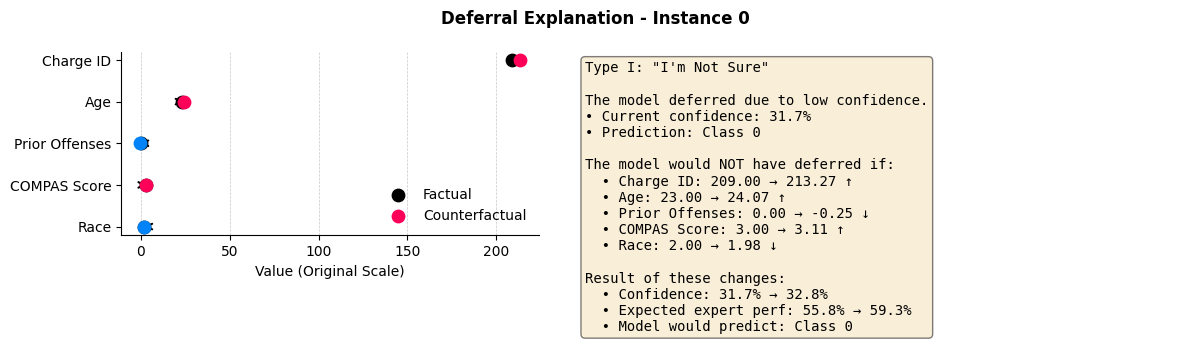


=== TikZ Code ===

% Instance 0 - Type I: ``I'm Not Sure''
\begin{tikzpicture}[
    font=\sffamily,
    node distance=0.15cm,
    col_width/.style={text width=4.5cm, align=left},
    header/.style={font=\bfseries\small, col_width},
    label/.style={font=\tiny\scshape, text=clr_gray, inner sep=0pt, col_width},
    content/.style={font=\scriptsize, col_width, inner sep=2pt},
    divider/.style={thick, dashed, clr_gray!40}
]

    % Header
    \node[header, text=clr_blue] (h1) {Type I: ``I'm Not Sure''};
    
    % Input Features
    \node[label, below=0.2cm of h1] (l1_feat) {Input Features};
    \node[content, below=0.05cm of l1_feat] (c1_feat) {
        Charge ID: 209.0\\ 
        Age: 23\\ 
        Prior Offenses: 0
    };
    \node[content, below=0.1cm of c1_feat] (pred1) {Prediction: \textbf{DEFERRED}};

    % Divider
    \draw[divider] ($(pred1.south west)$) -- ($(pred1.south east)$);

    % Diagnosis
    \node[label, below=0.2cm of pred1] (l1_diag) {Diagnosis};
    \node[content, 

In [63]:
# Preview one Type I example
if type_i_examples:
    # Find index in df_merged (not the original index)
    type_i_idx = list(df_merged.index).index(type_i_examples[0])
    preview_instance(type_i_idx)

=== Instance 8 (mixed) ===

Original features:
  Race: 2.00
  Sex: -0.00
  Age: 29.00
  Juvenile Felonies: -0.00
  Juvenile Misdemeanors: -0.00
  Prior Offenses: 1.00
  Charge ID: 159.00
  charge_degree (misd/fel): 1.00
  COMPAS Score: 9.00

Top feature changes:
  Charge ID: 159.00 → 136.48
  Age: 29.00 → 26.81
  Prior Offenses: 1.00 → 1.98
  COMPAS Score: 9.00 → 8.52
  Juvenile Misdemeanors: -0.00 → 0.07


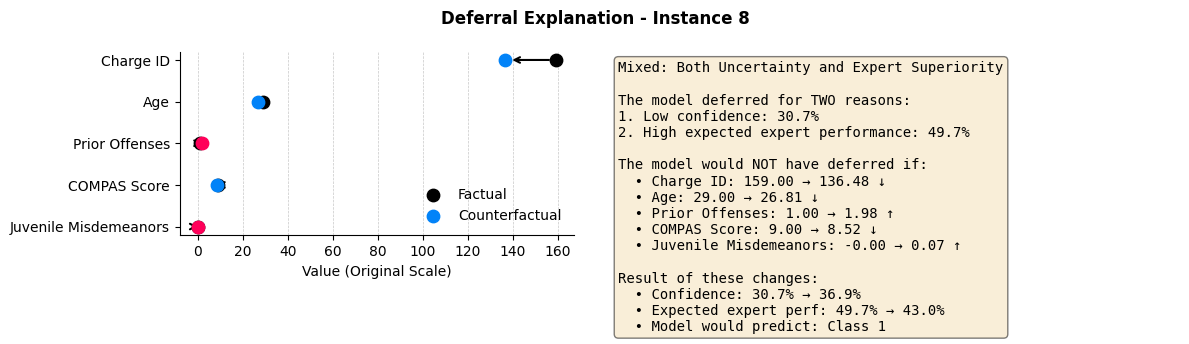


=== TikZ Code ===

% Instance 8 - Mixed Type
\begin{tikzpicture}[
    font=\sffamily,
    node distance=0.15cm,
    col_width/.style={text width=4.5cm, align=left},
    header/.style={font=\bfseries\small, col_width},
    label/.style={font=\tiny\scshape, text=clr_gray, inner sep=0pt, col_width},
    content/.style={font=\scriptsize, col_width, inner sep=2pt},
    divider/.style={thick, dashed, clr_gray!40}
]

    % Header
    \node[header, text=clr_purple] (h1) {Mixed Type};
    
    % Input Features
    \node[label, below=0.2cm of h1] (l1_feat) {Input Features};
    \node[content, below=0.05cm of l1_feat] (c1_feat) {
        Charge ID: 159.0\\ 
        Age: 29\\ 
        Prior Offenses: 1
    };
    \node[content, below=0.1cm of c1_feat] (pred1) {Prediction: \textbf{DEFERRED}};

    % Divider
    \draw[divider] ($(pred1.south west)$) -- ($(pred1.south east)$);

    % Diagnosis
    \node[label, below=0.2cm of pred1] (l1_diag) {Diagnosis};
    \node[content, below=0.05cm of l1_diag] (

In [64]:
# Preview one Mixed example
if mixed_examples:
    mixed_idx = list(df_merged.index).index(mixed_examples[0])
    preview_instance(mixed_idx)

## 9. Save Results DataFrame

In [39]:
# Save the full results dataframe for future use
results_path = f"{OUTPUT_DIR}/broward_counterfactuals_results.csv"
df_merged.to_csv(results_path, index=True)
print(f"Saved results to {results_path}")

# Also save scaler parameters
scaler_df = pd.DataFrame({
    'feature': feature_names,
    'mean': scaler.mean_,
    'std': scaler.scale_
})
scaler_path = f"{OUTPUT_DIR}/scaler_params.csv"
scaler_df.to_csv(scaler_path, index=False)
print(f"Saved scaler parameters to {scaler_path}")

Saved results to results/defer_figures/broward_counterfactuals_results.csv
Saved scaler parameters to results/defer_figures/scaler_params.csv


## 10. Summary Statistics

In [40]:
print("=== SUMMARY ===")
print(f"\nTotal test instances: {len(dataset.data_test)}")
print(f"Deferred instances: {metrics['n_defer']} ({metrics['n_defer']/len(dataset.data_test)*100:.1f}%)")
print(f"\nDeferral Type Breakdown:")
print(f"  Type I (uncertainty): {metrics['n_only_type1']} ({metrics['n_only_type1']/metrics['n_defer']*100:.1f}%)")
print(f"  Type II (expert superiority): {metrics['n_only_type2']} ({metrics['n_only_type2']/metrics['n_defer']*100:.1f}%)")
print(f"  Mixed: {metrics['n_mixed']} ({metrics['n_mixed']/metrics['n_defer']*100:.1f}%)")
print(f"\nModel Performance:")
print(f"  Classifier accuracy (all): {metrics.get('classifier_all_acc', 'N/A')}")
print(f"  System accuracy: {metrics.get('system_acc', 'N/A')}")
print(f"  Coverage (non-deferred): {1 - metrics.get('coverage', 0):.1%}")

=== SUMMARY ===

Total test instances: 200
Deferred instances: 5 (2.5%)

Deferral Type Breakdown:
  Type I (uncertainty): 2 (40.0%)
  Type II (expert superiority): 0 (0.0%)
  Mixed: 3 (60.0%)

Model Performance:
  Classifier accuracy (all): 0.6
  System accuracy: 0.605
  Coverage (non-deferred): 1.0%


In [43]:
if mixed_examples:
    mixed_idx = list(df_merged.index).index(mixed_examples[3])
    preview_instance(mixed_idx)

IndexError: list index out of range